<a href="https://colab.research.google.com/github/Nataliaa2102/dm4bi-2026-del/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees

> Goal of the session:
>
> - At the end of this activity, you will understand the basics of decision trees, how they work internally and how they are used in random forests. You will also see how models are evaluated and how we can try to explain their predictions.
>
> Scope of the session
>
> - Prepare a dataset for training a decision tree model.
> - Analyze the dataset and see how to split it into training and test sets.
> - Train a decision tree model using the `sklearn` library and observe how the trained model inference works.
> - Train a random forest model.
> - See how model performance can be evaluated.
> - Use cross-validation for robust model comparison.
> - Apply the full pipeline to a real-world dataset (Titanic).

## 1. Setup

### Dependencies

- ``dtreeviz`` 2.2.2
- ``ipython``
- ``nbformat``
- ``numpy`` 2.4.4
- ``pandas`` 3.0.2
- ``plotly`` 5.24.1
- ``pydotplus`` 2.0.2
- ``scikit-learn`` 1.8.0

In [ ]:
%pip install dtreeviz==2.2.2 ipython nbformat numpy==2.4.4 pandas==3.0.2 \
    plotly==5.24.1 pydotplus==2.0.2 scikit-learn==1.8.0

### Imports

In [30]:
import pickle
from io import StringIO
from pathlib import Path

import dtreeviz
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pydotplus
from IPython.display import Image
from plotly.subplots import make_subplots
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    export_graphviz,
)

In [31]:
iris = datasets.load_iris(as_frame=True)

## 2. Analysis

In [32]:
iris.frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


``iris`` is not a dataset, but a collection of datasets (``data``, ``target`` and both merged together as ``frame``).

In [33]:
X = iris.data
y = iris.target

If you notice the name of the variables above, you'll see the X's and y's.

In business terms: X is your table of inputs (customer age, purchase history, location), and y is what you're trying to predict (will they churn? which product will they buy?). The model learns a function that maps X to y.

In math notation, we define the dataset X as the array of feature vectors, each vector representing the description of a flower in our dataset, each feature representing an aspect of a flower). With all these values in X, we want to infer an approximate function $\hat{y}$, using the labeled dataset in variable `y` to better **fit** the data in `X`.

Or $\hat{y} = f(X)$

Here we also use 'y' as the name of the variable that holds the target variable (species)

In [34]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [35]:
y.to_numpy()

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

<Axes: >

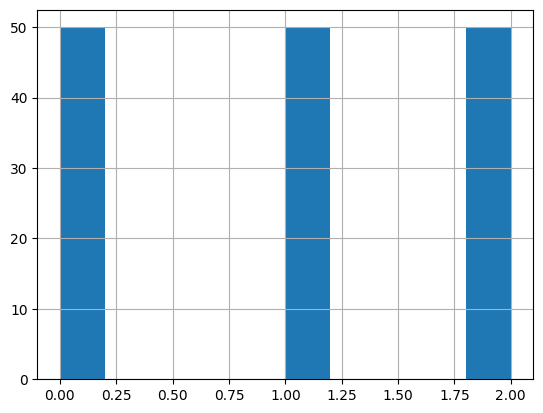

In [36]:
y.hist()

If all the values for the target occur in similar amounts, we can say that the dataset is balanced. If not, the dataset is **unbalanced**, which can be an issue when training models.

<details>
<summary>💡 Think about it first — click to reveal</summary>

**Is this dataset balanced? Why does balance matter?**

Yes — roughly 50 examples per class. Balance matters because a model trained on unbalanced data tends to favour the majority class. For example, if 90% of your training data is "not churn", a model can achieve 90% accuracy by always predicting "not churn" — without learning anything useful.

</details>

In [37]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [38]:
iris_df = X.copy()
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [39]:
species_dict = {0: "setosa", 1: "versicolor", 2: "virginica"}
iris_df["species"] = y.map(species_dict)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Each cell in this grid shows the relationship between two measurements. Hover over a point to see its values. Look at which groups (species) separate cleanly — those pairs are useful for classification.

In [40]:
px.scatter_matrix(iris_df, dimensions=iris.feature_names, title="Iris Feature Pairs")

In [41]:
px.scatter_matrix(
    iris_df,
    dimensions=iris.feature_names,
    color="species",
    opacity=0.4,
    title="Iris Feature Pairs by Species",
)

## 3. Model training

### Dividing the dataset into train and test datasets

We are going to create a decision tree with a partition between train and test of the data. Look at the variable *random_state* that is applied in the `train_test_split` function. By changing this variable, the random distribution between the train and test data will change.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=70,
    stratify=y,  # keeps class proportions equal in both splits
)

<details>
<summary>💡 Think about it first — click to reveal</summary>

**We split the data into training and test sets. Why must we evaluate the model on the test set and not the training set?**

If we test on the same data we trained on, the model already “knows” those examples — like a student who memorizes the answers to a practice exam. The test set contains data the model has never seen, so it measures whether the model actually learned the pattern, not just memorized the examples.

</details>

The random state or seed is a number that is used to initialize the random number generator. It is used to ensure that the random numbers generated are reproducible.

In [43]:
len(X_train)

112

In [44]:
len(X_test)

38

### Why dividing the dataset is important?

You want your model to generalize well, so sampling is important and you need to avoid data leakage, i.e. using the training dataset as the test dataset

Additional resources:
- [K Fold Cross Validation](https://www.datacamp.com/tutorial/k-fold-cross-validation)
- [K Fold Cross Validation in Scikit-Learn](https://www.cloudzilla.ai/dev-education/how-to-implement-k-fold-cross-validation)

### Training a Decision Tree Classifier

In decision trees we're creating structures like:

![](https://miro.com/blog/wp-content/uploads/2021/12/decision_tree_business_analysis.png)

In [45]:
# Create the model
dtree = DecisionTreeClassifier()

# Train the model
# X_train contains the feature vectors for examples of flowers
# y_train contains the classes of these flowers
dtree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### Exporting model to file

This can be used to create a flower classifier application, for example

In [46]:
# Saves file (serialized dtree object)
with Path("dtree_iris.pkl").open("wb") as f:  # wb stands for Write Binary
    pickle.dump(dtree, f)

> [!Warning]
> Some vulnerabilities have been found in the pickle file format. It can be useful for quickly testing and prototyping, but it is not recommended for production use, where other formats are recommended.

In [47]:
# Just showing the file was actually created
!ls | grep pkl

dtree_iris.pkl


## 4. Analyzing and evaluating the model

### Visualizing resulting decision tree

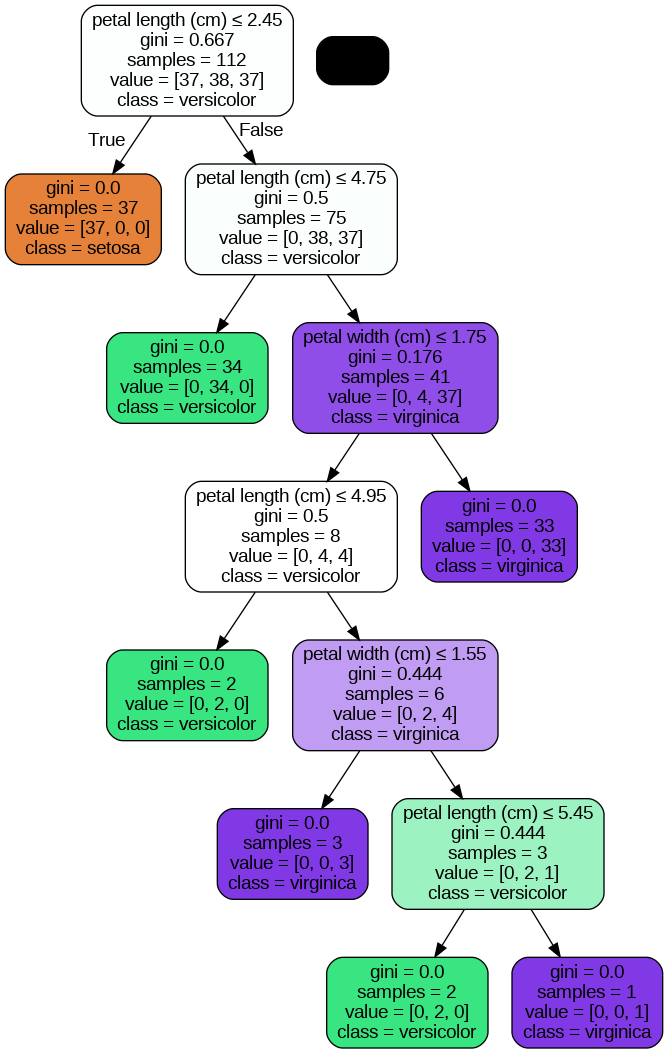

In [48]:
dot_data = StringIO()
export_graphviz(
    dtree,
    out_file=dot_data,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True,
)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

Imagine you are sorting customer support tickets — if every ticket in a pile is the same type of issue, the pile is "pure" and easy to route. A mixed pile of complaint types is "impure". The decision tree tries to create the purest possible piles with each split.

**Decision Trees** or CART (Classification and Regression Trees):

This method is based on the order of the data. It is, therefore, an iterative method in which each step will try to reduce the *impurity* of the data based on the variable to be predicted. Digging a bit:

1. We start with all our data in the same bag, therefore I have all the different categories mixed together.
By categories we mean the class, the target variable, i.e. what we're trying to predict in a classification task.

    1. The impurity of this data bag is modeled using the **Gini impurity index** (not to be confused with the Gini coefficient).
    1. Simplifying it, it could be seen as: If we introduce a new observation into our bag, whose response variable has been chosen based on the distribution of the different categories, what is the probability of being wrong if I try to classify it?
    1. In other terms: if I have a sack with two pears and two oranges, the impurity is 50%, since a new variable could be with the same probability either pear or orange.

2. Then, as we want to reduce this impurity, we will distribute the observations in different bags in each iteration based on the characteristics of our variables until we obtain groups where there is no possible error: Either everything is pears or everything is oranges.


### Exercise: Compute Gini Impurity

When a decision tree chooses where to split, it picks the split that makes the resulting groups as "pure" as possible — ideally, each group contains only one type of example. Gini impurity measures that purity: a score of 0 means perfectly pure (all one class); the higher the score, the more mixed the group.

$$
\text{Gini}(node) = 1 - \sum_{i=1}^{C} p_i^2
$$

where $C$ is the number of classes and $p_i = \frac{\text{count}_i}{\text{total samples}}$ is the proportion of class $i$ in the node.

**Exercise:** A node in your tree contains these samples: [3 setosa, 2 versicolor, 0 virginica]. Implement the function below to compute the Gini impurity of this node.

In [49]:
def gini_impurity(class_counts: list[int]) -> float:
    """
    Compute Gini impurity for a node.

    class_counts: list of per-class sample counts, e.g. [3, 2, 0]
    Returns: a value closer to 0 means purer (all one class = 0)
    """
    # def gini_impurity(class_counts: list[int]) -> float:
    total_samples = sum(class_counts)

    if total_samples == 0:
        return 0.0

    gini = 1.0

    for count in class_counts:
        p_i = count / total_samples
        gini -= p_i ** 2

    return gini
    ...  # noqa: PIE790

In [50]:
expected = 12 / 25  # exact value for [3, 2, 0]: 1 - (0.6² + 0.4² + 0²) = 0.48

assert abs(gini_impurity([3, 2, 0]) - expected) < 1e-9, (
    f"Got {gini_impurity([3, 2, 0]):.4f}, expected {expected:.4f}. "
    "Hint: p_i is the proportion of each class (count / total), not the count itself. "
    "Did you divide by the total number of samples before squaring?"
)
assert gini_impurity([5, 0, 0]) == 0.0, "A pure node (all one class) should have impurity 0."
assert abs(gini_impurity([2, 2]) - 0.5) < 1e-9, (
    "An equal two-class split should give 0.5. Check that you're squaring each proportion."
)
assert abs(gini_impurity([3, 3, 3]) - 2 / 3) < 1e-9, "A uniform three-class split should give 2/3 ≈ 0.667."
print("Correct!")

Correct!


<details>
<summary>💡 Reference solution — try it yourself first</summary>

```python
def gini_impurity(class_counts: list[int]) -> float:
    total = sum(class_counts)
    if total == 0:
        return 0.0
    return 1.0 - sum((c / total) ** 2 for c in class_counts)
```

</details>

We can see that there is a variable that strongly marks a first cut, so that already in the first split we obtain a partition without impurity. It is a model capable of obtaining a very accurate division of the data in very few steps.

> **Running in Google Colab?** `dtreeviz` renders visualizations by launching a program on your own computer, which is not possible in Colab's cloud environment. If you are using Colab, skip the `dtreeviz` cells — they will produce no output. The `export_graphviz` + `pydotplus` visualization in the “Visualising resulting decision tree” section above displays directly in the notebook and shows the same tree structure.
>
> Note: the same applies to the `dtreeviz` calls further below (the alternate `random_state` example and the train/val/test split example).

In [ ]:
viz = dtreeviz.model(
    dtree,
    X_train,
    y_train,
    target_name="Species",
    feature_names=iris.feature_names,
    class_names=list(iris.target_names),
)

viz.view(fontname="DejaVu Sans")

If we now repeat this process with a different distribution between train and test, which implies that the model has been trained with other data, by changing `random_state` to other value ...

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=60, stratify=y)

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

viz = dtreeviz.model(
    dtree,
    X_train,
    y_train,
    target_name="Species",
    feature_names=iris.feature_names,
    class_names=list(iris.target_names),
)

viz.view(fontname="DejaVu Sans")

### Some words about overfitting and underfitting

Sometimes you train a ML algorithm on the labeled dataset you have, but when faced with new unseen data the model starts performing badly. The model has memorized the training data rather than learning the underlying pattern. It performs well on examples it has seen before, but poorly on new data — like a student who memorized past exam answers without understanding the subject.

This is called **overfitting**. The opposite, **underfitting**, happens when the model is too simple and fails to capture the pattern even in the training data.

The visualization below shows the same algorithm with different `max_depth` settings on a simple 2D dataset. Run it as-is — the output is the lesson, not the code.

In [ ]:
X_2d, y_2d = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0, random_state=42)

x0, x1 = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y0, y1 = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x0, x1, 150), np.linspace(y0, y1, 150))
mesh = np.c_[xx.ravel(), yy.ravel()]

configs = [
    (1, "Underfit — max_depth=1"),
    (3, "Good fit — max_depth=3"),
    (20, "Overfit — max_depth=20"),
]

fig = make_subplots(rows=1, cols=3, subplot_titles=[title for _, title in configs])

for col, (depth, _) in enumerate(configs, start=1):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_2d, y_2d)
    Z = clf.predict(mesh).reshape(xx.shape)

    fig.add_trace(
        go.Heatmap(
            x=np.linspace(x0, x1, 150),
            y=np.linspace(y0, y1, 150),
            z=Z,
            showscale=False,
            colorscale="RdBu",
            opacity=0.4,
        ),
        row=1,
        col=col,
    )

    for cls, (marker_symbol, marker_color) in enumerate(zip(("circle", "x"), ("steelblue", "crimson"), strict=False)):
        mask = y_2d == cls
        fig.add_trace(
            go.Scatter(
                x=X_2d[mask, 0],
                y=X_2d[mask, 1],
                mode="markers",
                marker={"symbol": marker_symbol, "size": 6, "color": marker_color},
                showlegend=False,
            ),
            row=1,
            col=col,
        )

fig.update_layout(height=400, title_text="Decision Boundaries at Different Tree Depths")
fig.show()

### Train-validation-test split

One way to try to cope with overfitting is doing a more complex strategy for dividing the dataset into:

1. Train datased: used to train the model
1. Validation (or development) dataset: used to optimize our model parameters to achieve best accuracy possible
1. Test dataset: unseen data separated to test our model with possibly different patterns not found in previous datasets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

X_train, X_dev, y_train, y_dev = train_test_split(X_train, y_train, test_size=0.10, random_state=42, stratify=y_train)

# F-strings https://realpython.com/python-f-strings/
print(f"Training size: {len(X_train)}, Validation size: {len(X_dev)}, Test size: {len(X_test)}")

In [ ]:
# Create the model
dtree = DecisionTreeClassifier()

# Train the model
dtree.fit(X_train, y_train)

In [ ]:
viz = dtreeviz.model(
    dtree,
    X_train,
    y_train,
    target_name="Species",
    feature_names=iris.feature_names,
    class_names=list(iris.target_names),
)

viz.view(fontname="DejaVu Sans")

### Checking accuracy with the validation dataset

In [ ]:
y_dev_predicted = dtree.predict(X_dev)
y_dev_predicted

In [ ]:
print(f"Accuracy with validation dataset {accuracy_score(y_dev, y_dev_predicted)}")

At this point we can do multiple runs of train/validation checks to improve the accuracy score...

### Inferring over new unforeseen data (X_test)

In [ ]:
# The same but with X_test, y_test
y_test_predicted = dtree.predict(X_test)
y_test_predicted

In [ ]:
print(f"Accuracy with test dataset {accuracy_score(y_test, y_test_predicted)}")

## 5. Decision trees for regression problems

### Diabetes dataset

Target is a quantitative measure of disease progression one year after baseline

![](https://explained.ai/decision-tree-viz/images/samples/diabetes-TD-3-X.svg)

In the above example we can see Decision Trees create **LINEAR** decision boundaries for its variables.
This is amazing to generate (visual) explanations for your resulting model BUT...

What would happen if the feature vector distribution is like in the following image:

![](https://media.geeksforgeeks.org/wp-content/uploads/20200605170732/linearsep.png)

In this case we probably need Support Vector Machines (SVM), which are able to divide the feature space into curved decision boundaries.

### Additional reading

- [A visual introduction to machine learning](http://www.r2d3.us/visual-intro-to-machine-learning-part-1/)
- [Understanding Decision Trees with Python](https://www.datacamp.com/tutorial/decision-tree-classification-python)
- [4 Ways to Visualize Individual Decision Trees in a Random Forest](https://towardsdatascience.com/4-ways-to-visualize-individual-decision-trees-in-a-random-forest-7a9beda1d1b7)
- [How to Visualize a Random Forest with Fitted Parameters?](https://analyticsindiamag.com/how-to-visualize-a-random-forest-with-fitted-parameters/)
- [Understanding Random forest better through visualizations](https://garg-mohit851.medium.com/random-forest-visualization-3f76cdf6456f)

In [ ]:
# Load diabetes dataset (a regression target: disease progression score)
diabetes = datasets.load_diabetes(as_frame=True)
X_diabetes = diabetes.data
y_diabetes = diabetes.target
X_diabetes.head()

In [ ]:
X_diab_train, X_diab_test, y_diab_train, y_diab_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.25, random_state=42
)

reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
reg_tree.fit(X_diab_train, y_diab_train)

In [ ]:
# Visualize the regression tree — same pattern as the classifier tree above
dot_data = StringIO()
export_graphviz(
    reg_tree,
    out_file=dot_data,
    feature_names=X_diabetes.columns,
    filled=True,
    rounded=True,
    special_characters=True,
)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [ ]:
y_diab_pred = reg_tree.predict(X_diab_test)
print(f"MAE:  {mean_absolute_error(y_diab_test, y_diab_pred):.1f}")
print(f"R\u00b2:   {r2_score(y_diab_test, y_diab_pred):.3f}")

Unlike classifiers, leaf values in a regression tree are the **mean** of training samples that fell into that leaf — not a class label. MAE tells us the average prediction error in the original units; R² tells us how much of the variance the model explains (1.0 = perfect).

## 6. Improving the Model

There are two very useful techniques that allow us to create new models:

* **Bootstrap**: It is based on choosing subsamples of our data in a uniform way and with repetition, thus creating multiple smaller samples that share the distributions of the original sample.

* **Bagging**: Generate a bootstrap of size $n$, train a model on that subsample and repeat the process $m$ times.

In [ ]:
# Uses X_train, y_train from the train/val/test split above.
# Bootstrap: draw samples with replacement to create diverse training sets.

from scipy.stats import mode as _majority_vote

rng = np.random.default_rng(42)
n_trees = 5
trees: list[DecisionTreeClassifier] = []
tree_accuracies: list[float] = []

for i in range(n_trees):
    # Each tree trains on a different bootstrap sample — that's the source of diversity.
    idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train.iloc[idx]
    y_boot = y_train.iloc[idx]

    tree = DecisionTreeClassifier(random_state=42 + i)
    tree.fit(X_boot, y_boot)
    trees.append(tree)
    tree_accuracies.append(accuracy_score(y_test, tree.predict(X_test)))

In [ ]:
# Majority vote: for each test example, pick the class predicted by most trees.
all_preds = np.array([t.predict(X_test) for t in trees])  # shape: (n_trees, n_samples)
ensemble_pred = _majority_vote(all_preds, axis=0).mode
ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
print(f"Individual tree accuracies: {[round(a, 3) for a in tree_accuracies]}")
print(f"Ensemble accuracy:          {ensemble_accuracy:.3f}")

In [ ]:
fig = px.bar(
    x=[f"Tree {i + 1}" for i in range(n_trees)] + ["Ensemble"],
    y=[*tree_accuracies, ensemble_accuracy],
    labels={"x": "", "y": "Accuracy"},
    title="Individual Trees vs. Majority-Vote Ensemble",
    color=["individual"] * n_trees + ["ensemble"],
    color_discrete_map={"individual": "steelblue", "ensemble": "crimson"},
)
fig.show()

## 7. Random Forests

Now let's apply an *ensemble* method such as *Random Forest*, based on the results of multiple decision trees.



There are other types of combining classifiers (or ensemble methods), such as mean average, or the product rule, using a priory probability distributions and the confidence of the classification of each classifier.

Additional reading:

- [Scikit Learn ensemble methods](https://scikit-learn.org/stable/modules/ensemble.html)

### Training a Random Forest

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=100, stratify=y)

rf = RandomForestClassifier(n_jobs=-1)  # parallelize the execution
rf.fit(X_train, y_train)

Let's analyze the code ... ([RFs in Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html))

In [ ]:
help(rf)

The ``help`` function is very useful to understand the parameters of a function. You can also use the ``?`` operator in Jupyter notebooks to get help on a function.

### Real species

In [ ]:
y_test

### Predicting the class of test dataset

In [ ]:
predicted = rf.predict(X_test)
predicted

### Accuracy score

In [ ]:
accuracy_score(y_test, predicted)

In [ ]:
help(accuracy_score)

### Feature importance

In [ ]:
rf = RandomForestClassifier(n_jobs=4)
rf

In [ ]:
rf.fit(X_train, y_train)

In [ ]:
importances = rf.feature_importances_
importances

In [ ]:
indexes = np.argsort(importances)[::-1]
indexes

In [ ]:
X.columns

In [ ]:
# Map importances to species_names
names = [X.columns[i] for i in indexes]
names

In [ ]:
# Prepare a barplot with plotly
fig = px.bar(x=names, y=importances[indexes], labels={"x": "Features", "y": "Importance"}, title="Feature Importance")
fig.show()

In the code of the upper cell we see not only how we can apply a model, but that it contains the importance of the different *features* or predictor variables.

### Predict() function and confusion matrix

In [ ]:
rf_preds = rf.predict(X_test)
rf_conf_mat = confusion_matrix(y_test, rf_preds)
rf_conf_mat

In [ ]:
help(confusion_matrix)

You can get the accuracy score with data from confusion matrix

In [ ]:
# Convert to numpy
np_mat = np.asarray(rf_conf_mat)

acc = sum(np.diagonal(np_mat)) / np_mat.sum()
print(f"My accuracy is: {acc}")

### Confusion matrix visualization

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=rf_conf_mat, display_labels=iris.target_names)
disp.plot()

<details>
<summary>💡 Think about it first — click to reveal</summary>

**Looking at the confusion matrix, which species does the model confuse most with another? Why might this be?**

Versicolor and virginica are the hardest to separate. Look back at the scatter matrix — their feature distributions overlap significantly. Setosa is always cleanly separated because its measurements (especially petal length and width) are distinctly different from the other two.

</details>

## 8. Cross-Validation

So far we've evaluated every model on a single train/test split. But accuracy can vary depending on which examples land in which set — you saw this when changing `random_state` earlier. Cross-validation gives a more reliable estimate by repeating the evaluation across multiple splits.

The accuracy values here will differ from Section 7 — that section used one specific 67/33 split. Cross-validation averages over ten different splits of the full dataset, giving a more stable picture.

### How k-fold cross-validation works

1. Split the full dataset into *k* equal folds (typically 5 or 10).
2. For each fold: use it as the test set, train on the remaining k−1 folds.
3. Average the k accuracy scores — this is your cross-validated accuracy.

The result is less sensitive to any single lucky or unlucky split.

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# X, y = full iris dataset (defined in Section 2) — cross-validation handles
# the splitting internally, so we pass the complete data, not a pre-split subset.

# Single decision tree
dt_scores = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=cv, scoring="accuracy")

# Random forest (n_jobs not set here — cross_val_score runs folds sequentially,
# and nesting n_jobs=-1 inside cross_val_score can spawn excessive processes)
rf_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X,
    y,
    cv=cv,
    scoring="accuracy",
)

print(f"Decision Tree:  {dt_scores.mean():.3f} ± {dt_scores.std():.3f}  (per fold: {dt_scores.round(3)})")
print(f"Random Forest:  {rf_scores.mean():.3f} ± {rf_scores.std():.3f}  (per fold: {rf_scores.round(3)})")

In [ ]:
fig = go.Figure()
fig.add_trace(
    go.Box(
        y=dt_scores,
        name="Decision Tree",
        marker_color="steelblue",
        boxpoints="all",
        pointpos=0,
        jitter=0.3,
    )
)
fig.add_trace(
    go.Box(
        y=rf_scores,
        name="Random Forest",
        marker_color="crimson",
        boxpoints="all",
        pointpos=0,
        jitter=0.3,
    )
)
fig.update_layout(
    title="10-Fold Cross-Validation: Decision Tree vs. Random Forest",
    yaxis_title="Accuracy",
    showlegend=False,
)
fig.show()

<details>
<summary>💡 Think about it first — click to reveal</summary>

**Why does cross-validation give a more trustworthy accuracy estimate than a single train/test split?**

A single split can be lucky (easy test examples) or unlucky (hard ones). Cross-validation averages over multiple splits, so the estimate reflects typical performance rather than one random draw. The ± standard deviation tells you how stable the model is across different data samples.

</details>

## 9. Real-World Challenge: Titanic Survival

The iris dataset is clean and small — real data is messier. In this section you'll apply decision trees and random forests to the Titanic passenger dataset to predict survival. You'll encounter missing values, categorical features, and class imbalance.

**Your tasks:**
1. Load and explore the data
2. Handle missing values and encode categorical features
3. Train a decision tree and a random forest
4. Evaluate with cross-validation
5. Interpret feature importance — which factors predicted survival?

In [ ]:
TITANIC_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
titanic.head()

In [ ]:
titanic.info()

In [ ]:
survived_counts = titanic["Survived"].value_counts().reset_index()
survived_counts.columns = ["Survived", "Count"]
fig = px.bar(
    survived_counts,
    x="Survived",
    y="Count",
    labels={"Survived": "Survived (0=No, 1=Yes)"},
    title="Survival Distribution",
)
fig.show()

### Data Preparation

The dataset has issues you need to handle before training:

- **Missing values:** `Age` has ~20% missing, `Cabin` has ~77% missing, `Embarked` has 2 missing.
- **Categorical features:** `Sex` and `Embarked` need encoding; `Name`, `Ticket`, `Cabin` can be dropped for now.
- **Feature selection:** Not all columns are useful. `PassengerId`, `Name`, `Ticket`, `Cabin` are identifiers, not predictive features.

The cell below handles these steps. Read through it, then run it.

In [ ]:
# Select useful features
X_titanic = titanic[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]].copy()
y_titanic = titanic["Survived"]

# Fill missing values
X_titanic["Age"] = X_titanic["Age"].fillna(X_titanic["Age"].median())
X_titanic["Embarked"] = X_titanic["Embarked"].fillna(X_titanic["Embarked"].mode()[0])

# Encode categorical features
X_titanic["Sex"] = X_titanic["Sex"].map({"male": 0, "female": 1})

# One-hot encode Embarked (nominal variable — no ordinal relationship between ports)
X_titanic = pd.get_dummies(X_titanic, columns=["Embarked"], drop_first=True, dtype=int)

X_titanic.head()

### Exercise: Train, Evaluate, Interpret

Using what you learned in previous sections, complete the cells below:

1. Train a `DecisionTreeClassifier` and a `RandomForestClassifier` on the Titanic data.
2. Use 5-fold cross-validation to compare their accuracy (hint: reuse the `StratifiedKFold` pattern from Section 8).
3. Plot feature importance from the random forest — which features matter most for survival?

In [ ]:
# Hint: cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Your code here: train and cross-validate both models
...  # noqa: PIE790

In [ ]:
# Your code here: plot feature importance
...  # noqa: PIE790

<details>
<summary>💡 Reference solution — try it yourself first</summary>

```python
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_titanic = cross_val_score(
    DecisionTreeClassifier(random_state=42), X_titanic, y_titanic, cv=cv
)
rf_titanic = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_titanic, y_titanic, cv=cv,
)

print(f"Decision Tree: {dt_titanic.mean():.3f} ± {dt_titanic.std():.3f}")
print(f"Random Forest: {rf_titanic.mean():.3f} ± {rf_titanic.std():.3f}")

# Fit on full data to extract feature importances —
# cross-validation already gave us the accuracy estimate above.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_titanic, y_titanic)

feature_names = X_titanic.columns.tolist()
importances = rf_model.feature_importances_
fig = px.bar(
    x=feature_names,
    y=importances,
    labels={"x": "Feature", "y": "Importance"},
    title="Titanic — Feature Importance (Random Forest)",
)
fig.show()
```

</details>

### Discussion

Look at the feature importance chart. In the Titanic disaster:
- **Sex** is the strongest predictor — "women and children first" was a real policy.
- **Fare** and **Pclass** reflect socio-economic status — wealthier passengers had better access to lifeboats.
- **Age** matters — children were prioritized.

This is an example of how machine learning can surface historical patterns in data. The model doesn't "know" history — it finds statistical regularities that happen to align with documented facts.